# AI-Powered Adaptive Traffic & Emergency Mobility Management System

## Notebook 01 — Traffic Data Analysis

### Objective

This notebook is used to:

- Load traffic observation data
- Inspect and validate the dataset
- Clean missing or invalid values
- Analyse traffic volume by lane and vehicle type
- Study queue length and waiting-time patterns
- Prepare the dataset for later ML and traffic-control experiments

### Data Sources

The final dataset may contain:

- Real field observations
- AI / Computer-Vision generated traffic values
- SUMO simulation results

Each row contains a `data_source` field so that the origin of the data can always be identified.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [7]:
DATA_PATH = "../data/raw/traffic_data.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully!
Dataset shape: (0, 15)

Columns:
['timestamp', 'location', 'junction_id', 'lane', 'car_count', 'bike_count', 'bus_count', 'truck_count', 'total_vehicles', 'queue_length', 'avg_waiting_time', 'traffic_density', 'signal_state', 'emergency_vehicle', 'data_source']


In [4]:
from pathlib import Path

DATASET_ROOT = Path(
    "../data/public/pune_traffic/"
    "Heterogeneous Traffic Count Dataset, Pune (Jan 202/"
    "traffic/traffic"
)

csv_files = list(DATASET_ROOT.rglob("*.csv"))

print("Number of traffic CSV files:", len(csv_files))

for file in csv_files[:10]:
    print(file)

Number of traffic CSV files: 115
../data/public/pune_traffic/Heterogeneous Traffic Count Dataset, Pune (Jan 202/traffic/traffic/JehangirChowk/j1/j1_12.csv
../data/public/pune_traffic/Heterogeneous Traffic Count Dataset, Pune (Jan 202/traffic/traffic/JehangirChowk/j1/j1_13.csv
../data/public/pune_traffic/Heterogeneous Traffic Count Dataset, Pune (Jan 202/traffic/traffic/JehangirChowk/j1/j1_11.csv
../data/public/pune_traffic/Heterogeneous Traffic Count Dataset, Pune (Jan 202/traffic/traffic/JehangirChowk/j1/j1_14.csv
../data/public/pune_traffic/Heterogeneous Traffic Count Dataset, Pune (Jan 202/traffic/traffic/JehangirChowk/j1/j1_18_one.csv
../data/public/pune_traffic/Heterogeneous Traffic Count Dataset, Pune (Jan 202/traffic/traffic/JehangirChowk/j1/j1_15.csv
../data/public/pune_traffic/Heterogeneous Traffic Count Dataset, Pune (Jan 202/traffic/traffic/JehangirChowk/j1/j1_17.csv
../data/public/pune_traffic/Heterogeneous Traffic Count Dataset, Pune (Jan 202/traffic/traffic/JehangirChowk/

In [5]:
all_data = []

for file in csv_files:
    temp = pd.read_csv(file)

    relative = file.relative_to(DATASET_ROOT)
    parts = relative.parts

    # Folder structure:
    # intersection / camera / filename.csv

    temp["intersection"] = parts[0]
    temp["camera"] = parts[1]
    temp["source_file"] = file.name

    all_data.append(temp)

traffic = pd.concat(all_data, ignore_index=True)

print("Combined dataset created successfully!")
print("Dataset shape:", traffic.shape)

traffic.head(10)

Combined dataset created successfully!
Dataset shape: (68064443, 9)


,Time,Direction,car,motorbike,bus,truck,intersection,camera,source_file
0,08:59:57,UP,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv
1,08:59:57,DOWN,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv
2,08:59:57,RIGHT,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv
3,08:59:57,LEFT,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv
4,08:59:57,UP,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv
5,08:59:57,DOWN,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv
6,08:59:57,RIGHT,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv
7,08:59:57,LEFT,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv
8,08:59:57,UP,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv
9,08:59:57,DOWN,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [6]:
print("Intersections:")
print(traffic["intersection"].unique())

print("\nCameras:")
print(traffic["camera"].unique())

print("\nDirections:")
print(traffic["Direction"].unique())

print("\nMissing values:")
print(traffic.isnull().sum())

Intersections:
['JehangirChowk' 'AlankarChowk' 'RTOChowk']

Cameras:
['j1' 'j2' 'j3' 'a3' 'a2' 'r1' 'r3' 'r2']

Directions:
['UP' 'DOWN' 'RIGHT' 'LEFT' nan]

Missing values:
Time            109103
Direction       109103
car             109103
motorbike       109103
bus             109103
truck           109103
intersection         0
camera               0
source_file          0
dtype: int64


In [7]:
print("Vehicle statistics:")

print(
    traffic[
        ["car", "motorbike", "bus", "truck"]
    ].describe()
)

Vehicle statistics:
                car     motorbike           bus         truck
count  6.795534e+07  6.795534e+07  6.795534e+07  6.795534e+07
mean   3.271893e+02  2.726687e+02  2.980750e+01  5.574692e+01
std    6.816920e+02  4.673643e+02  5.521473e+01  9.250051e+01
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
25%    1.300000e+01  1.000000e+01  1.000000e+00  2.000000e+00
50%    8.300000e+01  7.500000e+01  6.000000e+00  1.500000e+01
75%    3.530000e+02  3.070000e+02  3.100000e+01  6.400000e+01
max    9.119000e+03  3.429000e+03  4.730000e+02  6.630000e+02


In [8]:
traffic["total_vehicles"] = (
    traffic["car"].fillna(0)
    + traffic["motorbike"].fillna(0)
    + traffic["bus"].fillna(0)
    + traffic["truck"].fillna(0)
)

print("Total rows:", len(traffic))
print("Rows with vehicles:", (traffic["total_vehicles"] > 0).sum())
print("Zero-vehicle rows:", (traffic["total_vehicles"] == 0).sum())

print("\nMaximum vehicles in one record:")
print(traffic["total_vehicles"].max())

Total rows: 68064443
Rows with vehicles: 66639690
Zero-vehicle rows: 1424753

Maximum vehicles in one record:
9541.0


In [9]:
traffic["total_vehicles"] = (
    traffic["car"].fillna(0)
    + traffic["motorbike"].fillna(0)
    + traffic["bus"].fillna(0)
    + traffic["truck"].fillna(0)
)

traffic.sort_values("total_vehicles", ascending=False)[
    [
        "Time",
        "Direction",
        "car",
        "motorbike",
        "bus",
        "truck",
        "total_vehicles",
        "intersection",
        "camera",
        "source_file"
    ]
].head(20)

,Time,Direction,car,motorbike,bus,truck,total_vehicles,intersection,camera,source_file
30948271,11:26:58,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948387,11:26:59,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948103,11:26:56,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948107,11:26:56,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948111,11:26:56,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948115,11:26:56,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948119,11:26:57,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948123,11:26:57,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948127,11:26:57,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948131,11:26:57,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv


In [10]:
sample_file = csv_files[0]

sample_df = pd.read_csv(sample_file)

print("Sample file:", sample_file)
print("Shape:", sample_df.shape)

display(sample_df.head(20))
display(sample_df.tail(20))

Sample file: ../data/public/pune_traffic/Heterogeneous Traffic Count Dataset, Pune (Jan 202/traffic/traffic/JehangirChowk/j1/j1_12.csv
Shape: (885100, 6)


,Time,Direction,car,motorbike,bus,truck
0,08:59:57,UP,0.0,0.0,0.0,0.0
1,08:59:57,DOWN,0.0,0.0,0.0,0.0
2,08:59:57,RIGHT,0.0,0.0,0.0,0.0
3,08:59:57,LEFT,0.0,0.0,0.0,0.0
4,08:59:57,UP,0.0,0.0,0.0,0.0
5,08:59:57,DOWN,0.0,0.0,0.0,0.0
6,08:59:57,RIGHT,0.0,0.0,0.0,0.0
7,08:59:57,LEFT,0.0,0.0,0.0,0.0
8,08:59:57,UP,0.0,0.0,0.0,0.0
9,08:59:57,DOWN,0.0,0.0,0.0,0.0


,Time,Direction,car,motorbike,bus,truck
885080,NaN,NaN,NaN,NaN,NaN,NaN
885081,NaN,NaN,NaN,NaN,NaN,NaN
885082,NaN,NaN,NaN,NaN,NaN,NaN
885083,NaN,NaN,NaN,NaN,NaN,NaN
885084,NaN,NaN,NaN,NaN,NaN,NaN
885085,NaN,NaN,NaN,NaN,NaN,NaN
885086,NaN,NaN,NaN,NaN,NaN,NaN
885087,NaN,NaN,NaN,NaN,NaN,NaN
885088,NaN,NaN,NaN,NaN,NaN,NaN
885089,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
print("Unique timestamps:", sample_df["Time"].nunique())
print("Total rows:", len(sample_df))

print(sample_df["Time"].value_counts().head(20))

Unique timestamps: 8788
Total rows: 885100
Time
08:59:57    100
10:37:39    100
10:37:33    100
10:37:34    100
10:37:35    100
10:37:36    100
10:37:37    100
10:37:38    100
10:37:40    100
10:37:14    100
10:37:41    100
10:37:42    100
10:37:43    100
10:37:44    100
10:37:45    100
10:37:46    100
10:37:32    100
10:37:31    100
10:37:30    100
10:37:29    100
Name: count, dtype: int64


In [12]:
check_time = "08:59:57"

rows_at_time = sample_df[sample_df["Time"] == check_time]

print("Rows at", check_time, ":", len(rows_at_time))

display(rows_at_time.head(30))

Rows at 08:59:57 : 100


,Time,Direction,car,motorbike,bus,truck
0,08:59:57,UP,0.0,0.0,0.0,0.0
1,08:59:57,DOWN,0.0,0.0,0.0,0.0
2,08:59:57,RIGHT,0.0,0.0,0.0,0.0
3,08:59:57,LEFT,0.0,0.0,0.0,0.0
4,08:59:57,UP,0.0,0.0,0.0,0.0
5,08:59:57,DOWN,0.0,0.0,0.0,0.0
6,08:59:57,RIGHT,0.0,0.0,0.0,0.0
7,08:59:57,LEFT,0.0,0.0,0.0,0.0
8,08:59:57,UP,0.0,0.0,0.0,0.0
9,08:59:57,DOWN,0.0,0.0,0.0,0.0


In [13]:
print("Unique rows at this timestamp:")
print(rows_at_time.drop_duplicates().shape[0])

display(rows_at_time.drop_duplicates())

Unique rows at this timestamp:
4


,Time,Direction,car,motorbike,bus,truck
0,08:59:57,UP,0.0,0.0,0.0,0.0
1,08:59:57,DOWN,0.0,0.0,0.0,0.0
2,08:59:57,RIGHT,0.0,0.0,0.0,0.0
3,08:59:57,LEFT,0.0,0.0,0.0,0.0


In [14]:
print(rows_at_time["Direction"].value_counts())

Direction
UP       25
DOWN     25
RIGHT    25
LEFT     25
Name: count, dtype: int64


In [15]:
for direction in ["UP", "DOWN", "LEFT", "RIGHT"]:
    subset = rows_at_time[rows_at_time["Direction"] == direction]

    print("\nDirection:", direction)
    print("Rows:", len(subset))
    print("Unique combinations:")

    display(
        subset[
            ["car", "motorbike", "bus", "truck"]
        ].drop_duplicates()
    )


Direction: UP
Rows: 25
Unique combinations:


,car,motorbike,bus,truck
0,0.0,0.0,0.0,0.0



Direction: DOWN
Rows: 25
Unique combinations:


,car,motorbike,bus,truck
1,0.0,0.0,0.0,0.0



Direction: LEFT
Rows: 25
Unique combinations:


,car,motorbike,bus,truck
3,0.0,0.0,0.0,0.0



Direction: RIGHT
Rows: 25
Unique combinations:


,car,motorbike,bus,truck
2,0.0,0.0,0.0,0.0


In [16]:
traffic.sort_values(
    "total_vehicles",
    ascending=False
)[
    [
        "Time",
        "Direction",
        "car",
        "motorbike",
        "bus",
        "truck",
        "total_vehicles",
        "intersection",
        "camera",
        "source_file"
    ]
].head(20)

,Time,Direction,car,motorbike,bus,truck,total_vehicles,intersection,camera,source_file
30948271,11:26:58,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948387,11:26:59,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948103,11:26:56,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948107,11:26:56,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948111,11:26:56,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948115,11:26:56,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948119,11:26:57,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948123,11:26:57,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948127,11:26:57,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv
30948131,11:26:57,UP,9119.0,208.0,93.0,121.0,9541.0,AlankarChowk,a3,a3_15.csv


In [17]:
file_check = traffic[
    (traffic["intersection"] == "AlankarChowk") &
    (traffic["camera"] == "a3") &
    (traffic["source_file"] == "a3_15.csv") &
    (traffic["Direction"] == "UP")
][["Time", "car", "motorbike", "bus", "truck"]]

# Remove repeated identical states
changes = file_check.drop_duplicates(
    subset=["car", "motorbike", "bus", "truck"],
    keep="first"
)

print("Original UP rows:", len(file_check))
print("Unique count states:", len(changes))

display(changes.head(30))

Original UP rows: 220733
Unique count states: 9257


,Time,car,motorbike,bus,truck
30066219,08:59:58,0.0,0.0,0.0,0.0
30066259,08:59:58,1.0,0.0,0.0,0.0
30066271,08:59:58,2.0,0.0,0.0,0.0
30066275,08:59:58,3.0,0.0,0.0,0.0
30066279,08:59:58,4.0,0.0,0.0,0.0
30066283,08:59:58,5.0,0.0,0.0,0.0
30066287,08:59:58,6.0,0.0,0.0,0.0
30066303,08:59:58,7.0,0.0,0.0,0.0
30066547,09:00:01,8.0,0.0,0.0,0.0
30066875,09:00:04,9.0,0.0,0.0,0.0


In [18]:
display(changes.tail(30))

,Time,car,motorbike,bus,truck
30935551,11:24:51,9090.0,208.0,92.0,121.0
30935767,11:24:53,9091.0,208.0,92.0,121.0
30936027,11:24:56,9092.0,208.0,92.0,121.0
30936899,11:25:04,9093.0,208.0,92.0,121.0
30936947,11:25:05,9094.0,208.0,92.0,121.0
30936983,11:25:05,9095.0,208.0,92.0,121.0
30937103,11:25:06,9096.0,208.0,92.0,121.0
30937183,11:25:07,9097.0,208.0,92.0,121.0
30937343,11:25:09,9098.0,208.0,92.0,121.0
30937347,11:25:09,9099.0,208.0,92.0,121.0


In [19]:
test_df = pd.read_csv(csv_files[0])

# Convert time
test_df["Time_dt"] = pd.to_datetime(
    test_df["Time"],
    format="%H:%M:%S",
    errors="coerce"
)

# For each timestamp and direction, keep the final cumulative count
# This removes repeated duplicate states while preserving increments
collapsed = (
    test_df
    .groupby(["Time_dt", "Direction"], as_index=False)
    [["car", "motorbike", "bus", "truck"]]
    .max()
    .sort_values(["Direction", "Time_dt"])
)

print("Raw rows:", len(test_df))
print("Collapsed rows:", len(collapsed))

display(collapsed.head(20))

Raw rows: 885100
Collapsed rows: 35152


,Time_dt,Direction,car,motorbike,bus,truck
0,1900-01-01 08:59:57,DOWN,0.0,0.0,0.0,0.0
4,1900-01-01 08:59:58,DOWN,1.0,0.0,0.0,0.0
8,1900-01-01 08:59:59,DOWN,1.0,0.0,0.0,0.0
12,1900-01-01 09:00:00,DOWN,1.0,0.0,0.0,0.0
16,1900-01-01 09:00:01,DOWN,1.0,0.0,0.0,0.0
20,1900-01-01 09:00:02,DOWN,2.0,0.0,0.0,0.0
24,1900-01-01 09:00:03,DOWN,3.0,0.0,0.0,0.0
28,1900-01-01 09:00:04,DOWN,3.0,1.0,0.0,0.0
32,1900-01-01 09:00:05,DOWN,3.0,1.0,0.0,0.0
36,1900-01-01 09:00:06,DOWN,3.0,1.0,0.0,0.0


In [20]:
vehicle_cols = ["car", "motorbike", "bus", "truck"]

for col in vehicle_cols:
    collapsed[f"new_{col}"] = (
        collapsed
        .groupby("Direction")[col]
        .diff()
    )

# Detect counter resets / invalid negative differences
for col in vehicle_cols:
    collapsed[f"reset_{col}"] = collapsed[f"new_{col}"] < 0

    collapsed.loc[
        collapsed[f"new_{col}"] < 0,
        f"new_{col}"
    ] = 0

# First observation of each direction has no previous value
for col in vehicle_cols:
    collapsed[f"new_{col}"] = (
        collapsed[f"new_{col}"]
        .fillna(0)
    )

collapsed["new_total"] = (
    collapsed["new_car"]
    + collapsed["new_motorbike"]
    + collapsed["new_bus"]
    + collapsed["new_truck"]
)

display(
    collapsed[
        [
            "Time_dt",
            "Direction",
            "car",
            "new_car",
            "motorbike",
            "new_motorbike",
            "bus",
            "new_bus",
            "truck",
            "new_truck",
            "new_total"
        ]
    ].tail(30)
)

,Time_dt,Direction,car,new_car,motorbike,new_motorbike,bus,new_bus,truck,new_truck,new_total
35035,1900-01-01 11:25:55,UP,131.0,0.0,173.0,0.0,11.0,0.0,16.0,0.0,0.0
35039,1900-01-01 11:25:56,UP,131.0,0.0,173.0,0.0,11.0,0.0,16.0,0.0,0.0
35043,1900-01-01 11:25:57,UP,131.0,0.0,173.0,0.0,11.0,0.0,16.0,0.0,0.0
35047,1900-01-01 11:25:58,UP,131.0,0.0,173.0,0.0,11.0,0.0,16.0,0.0,0.0
35051,1900-01-01 11:25:59,UP,131.0,0.0,173.0,0.0,11.0,0.0,16.0,0.0,0.0
35055,1900-01-01 11:26:00,UP,131.0,0.0,174.0,1.0,11.0,0.0,16.0,0.0,1.0
35059,1900-01-01 11:26:01,UP,131.0,0.0,174.0,0.0,11.0,0.0,16.0,0.0,0.0
35063,1900-01-01 11:26:02,UP,131.0,0.0,174.0,0.0,11.0,0.0,16.0,0.0,0.0
35067,1900-01-01 11:26:03,UP,131.0,0.0,174.0,0.0,11.0,0.0,16.0,0.0,0.0
35071,1900-01-01 11:26:04,UP,131.0,0.0,174.0,0.0,11.0,0.0,16.0,0.0,0.0


In [21]:
collapsed["interval_5min"] = collapsed["Time_dt"].dt.floor("5min")

five_min = (
    collapsed
    .groupby(
        ["interval_5min", "Direction"],
        as_index=False
    )[
        [
            "new_car",
            "new_motorbike",
            "new_bus",
            "new_truck",
            "new_total"
        ]
    ]
    .sum()
)

display(five_min.head(20))

,interval_5min,Direction,new_car,new_motorbike,new_bus,new_truck,new_total
0,1900-01-01 08:55:00,DOWN,1.0,0.0,0.0,0.0,1.0
1,1900-01-01 08:55:00,LEFT,1.0,0.0,0.0,0.0,1.0
2,1900-01-01 08:55:00,RIGHT,0.0,0.0,0.0,0.0,0.0
3,1900-01-01 08:55:00,UP,0.0,0.0,0.0,0.0,0.0
4,1900-01-01 09:00:00,DOWN,77.0,122.0,3.0,10.0,212.0
5,1900-01-01 09:00:00,LEFT,58.0,1.0,0.0,0.0,59.0
6,1900-01-01 09:00:00,RIGHT,25.0,19.0,2.0,11.0,57.0
7,1900-01-01 09:00:00,UP,3.0,1.0,0.0,0.0,4.0
8,1900-01-01 09:05:00,DOWN,111.0,124.0,2.0,9.0,246.0
9,1900-01-01 09:05:00,LEFT,43.0,0.0,0.0,1.0,44.0


In [22]:
from pathlib import Path
import pandas as pd

vehicle_cols = ["car", "motorbike", "bus", "truck"]

processed_files = []

for i, file in enumerate(csv_files, start=1):

    df_file = pd.read_csv(file)

    # Time conversion
    df_file["Time_dt"] = pd.to_datetime(
        df_file["Time"],
        format="%H:%M:%S",
        errors="coerce"
    )

    # Remove invalid time rows
    df_file = df_file.dropna(subset=["Time_dt"])

    # Collapse repeated cumulative states at each second/direction
    collapsed_file = (
        df_file
        .groupby(["Time_dt", "Direction"], as_index=False)
        [vehicle_cols]
        .max()
        .sort_values(["Direction", "Time_dt"])
    )

    # Calculate true new vehicle arrivals
    for col in vehicle_cols:
        diff = (
            collapsed_file
            .groupby("Direction")[col]
            .diff()
        )

        # Negative values indicate counter resets
        diff = diff.where(diff >= 0, 0)

        collapsed_file[f"new_{col}"] = diff.fillna(0)

    collapsed_file["total_vehicles"] = (
        collapsed_file["new_car"]
        + collapsed_file["new_motorbike"]
        + collapsed_file["new_bus"]
        + collapsed_file["new_truck"]
    )

    # 5-minute interval
    collapsed_file["interval_5min"] = (
        collapsed_file["Time_dt"].dt.floor("5min")
    )

    # Metadata from folder structure
    relative = file.relative_to(DATASET_ROOT)
    parts = relative.parts

    intersection = parts[0]
    camera = parts[1]
    source_file = file.name

    aggregated = (
        collapsed_file
        .groupby(
            ["interval_5min", "Direction"],
            as_index=False
        )[
            [
                "new_car",
                "new_motorbike",
                "new_bus",
                "new_truck",
                "total_vehicles"
            ]
        ]
        .sum()
    )

    aggregated["intersection"] = intersection
    aggregated["camera"] = camera
    aggregated["source_file"] = source_file

    processed_files.append(aggregated)

    if i % 10 == 0:
        print(f"Processed {i}/{len(csv_files)} files")

pune_5min = pd.concat(processed_files, ignore_index=True)

print("\nProcessing complete!")
print("Final shape:", pune_5min.shape)

display(pune_5min.head(20))

Processed 10/115 files
Processed 20/115 files
Processed 30/115 files
Processed 40/115 files
Processed 50/115 files
Processed 60/115 files
Processed 70/115 files
Processed 80/115 files
Processed 90/115 files
Processed 100/115 files
Processed 110/115 files

Processing complete!
Final shape: (9736, 10)


,interval_5min,Direction,new_car,new_motorbike,new_bus,new_truck,total_vehicles,intersection,camera,source_file
0,1900-01-01 08:55:00,DOWN,1.0,0.0,0.0,0.0,1.0,JehangirChowk,j1,j1_12.csv
1,1900-01-01 08:55:00,LEFT,1.0,0.0,0.0,0.0,1.0,JehangirChowk,j1,j1_12.csv
2,1900-01-01 08:55:00,RIGHT,0.0,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv
3,1900-01-01 08:55:00,UP,0.0,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv
4,1900-01-01 09:00:00,DOWN,77.0,122.0,3.0,10.0,212.0,JehangirChowk,j1,j1_12.csv
5,1900-01-01 09:00:00,LEFT,58.0,1.0,0.0,0.0,59.0,JehangirChowk,j1,j1_12.csv
6,1900-01-01 09:00:00,RIGHT,25.0,19.0,2.0,11.0,57.0,JehangirChowk,j1,j1_12.csv
7,1900-01-01 09:00:00,UP,3.0,1.0,0.0,0.0,4.0,JehangirChowk,j1,j1_12.csv
8,1900-01-01 09:05:00,DOWN,111.0,124.0,2.0,9.0,246.0,JehangirChowk,j1,j1_12.csv
9,1900-01-01 09:05:00,LEFT,43.0,0.0,0.0,1.0,44.0,JehangirChowk,j1,j1_12.csv


In [23]:
pune_5min = pune_5min.rename(
    columns={
        "interval_5min": "time",
        "Direction": "direction",
        "new_car": "car_count",
        "new_motorbike": "bike_count",
        "new_bus": "bus_count",
        "new_truck": "truck_count"
    }
)

pune_5min.head()

,time,direction,car_count,bike_count,bus_count,truck_count,total_vehicles,intersection,camera,source_file
0,1900-01-01 08:55:00,DOWN,1.0,0.0,0.0,0.0,1.0,JehangirChowk,j1,j1_12.csv
1,1900-01-01 08:55:00,LEFT,1.0,0.0,0.0,0.0,1.0,JehangirChowk,j1,j1_12.csv
2,1900-01-01 08:55:00,RIGHT,0.0,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv
3,1900-01-01 08:55:00,UP,0.0,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv
4,1900-01-01 09:00:00,DOWN,77.0,122.0,3.0,10.0,212.0,JehangirChowk,j1,j1_12.csv


In [24]:
pune_5min["total_vehicles"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
)

count    9736.000000
mean       48.333402
std        69.576094
min         0.000000
25%         4.000000
50%        24.000000
75%        74.000000
90%       131.000000
95%       153.000000
max      1586.000000
Name: total_vehicles, dtype: float64

In [25]:
OUTPUT_PATH = "../data/processed/pune_traffic_5min.csv"

pune_5min.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Saved cleaned dataset:")
print(OUTPUT_PATH)

Saved cleaned dataset:
../data/processed/pune_traffic_5min.csv


In [26]:
clean_df = pd.read_csv("../data/processed/pune_traffic_5min.csv")

print("Clean dataset loaded successfully!")
print("Shape:", clean_df.shape)

display(clean_df.head(10))

Clean dataset loaded successfully!
Shape: (9736, 10)


,time,direction,car_count,bike_count,bus_count,truck_count,total_vehicles,intersection,camera,source_file
0,1900-01-01 08:55:00,DOWN,1.0,0.0,0.0,0.0,1.0,JehangirChowk,j1,j1_12.csv
1,1900-01-01 08:55:00,LEFT,1.0,0.0,0.0,0.0,1.0,JehangirChowk,j1,j1_12.csv
2,1900-01-01 08:55:00,RIGHT,0.0,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv
3,1900-01-01 08:55:00,UP,0.0,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv
4,1900-01-01 09:00:00,DOWN,77.0,122.0,3.0,10.0,212.0,JehangirChowk,j1,j1_12.csv
5,1900-01-01 09:00:00,LEFT,58.0,1.0,0.0,0.0,59.0,JehangirChowk,j1,j1_12.csv
6,1900-01-01 09:00:00,RIGHT,25.0,19.0,2.0,11.0,57.0,JehangirChowk,j1,j1_12.csv
7,1900-01-01 09:00:00,UP,3.0,1.0,0.0,0.0,4.0,JehangirChowk,j1,j1_12.csv
8,1900-01-01 09:05:00,DOWN,111.0,124.0,2.0,9.0,246.0,JehangirChowk,j1,j1_12.csv
9,1900-01-01 09:05:00,LEFT,43.0,0.0,0.0,1.0,44.0,JehangirChowk,j1,j1_12.csv


In [27]:
print("Columns:")
print(clean_df.columns.tolist())

print("\nMissing values:")
print(clean_df.isnull().sum())

print("\nDuplicate rows:")
print(clean_df.duplicated().sum())

Columns:
['time', 'direction', 'car_count', 'bike_count', 'bus_count', 'truck_count', 'total_vehicles', 'intersection', 'camera', 'source_file']

Missing values:
time              0
direction         0
car_count         0
bike_count        0
bus_count         0
truck_count       0
total_vehicles    0
intersection      0
camera            0
source_file       0
dtype: int64

Duplicate rows:
0


In [28]:
display(
    clean_df[
        [
            "car_count",
            "bike_count",
            "bus_count",
            "truck_count",
            "total_vehicles"
        ]
    ].describe()
)

,car_count,bike_count,bus_count,truck_count,total_vehicles
count,9736.000000,9736.000000,9736.000000,9736.000000,9736.000000
mean,23.896364,18.305156,2.099425,4.032457,48.333402
std,55.290491,24.672433,3.951734,5.871101,69.576094
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,4.000000
50%,9.000000,8.000000,0.000000,1.000000,24.000000
75%,32.000000,26.000000,3.000000,6.000000,74.000000
max,1564.000000,234.000000,110.000000,136.000000,1586.000000


In [29]:
traffic_stats = clean_df["total_vehicles"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
)

display(traffic_stats)

count    9736.000000
mean       48.333402
std        69.576094
min         0.000000
25%         4.000000
50%        24.000000
75%        74.000000
90%       131.000000
95%       153.000000
max      1586.000000
Name: total_vehicles, dtype: float64

car_count      232655.0
bike_count     178219.0
bus_count       20440.0
truck_count     39260.0
dtype: float64

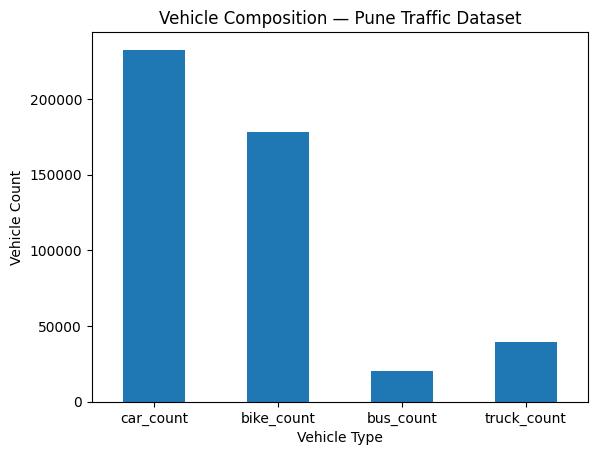

In [30]:
vehicle_totals = clean_df[
    ["car_count", "bike_count", "bus_count", "truck_count"]
].sum()

display(vehicle_totals)

vehicle_totals.plot(kind="bar")

plt.title("Vehicle Composition — Pune Traffic Dataset")
plt.xlabel("Vehicle Type")
plt.ylabel("Vehicle Count")
plt.xticks(rotation=0)
plt.show()

intersection
AlankarChowk     171321.0
JehangirChowk    154866.0
RTOChowk         144387.0
Name: total_vehicles, dtype: float64

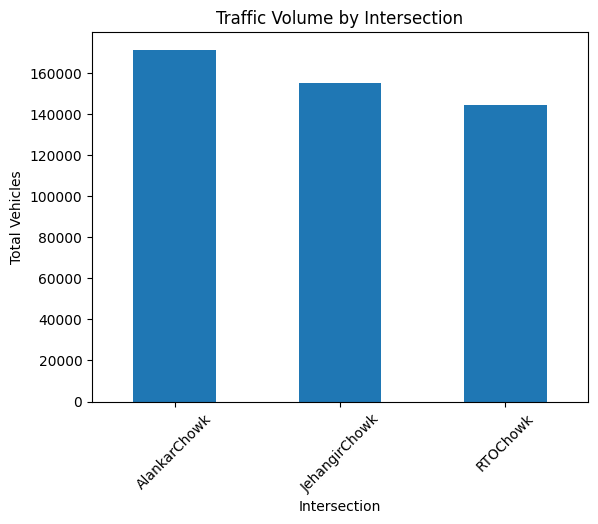

In [31]:
intersection_traffic = (
    clean_df.groupby("intersection")["total_vehicles"]
    .sum()
    .sort_values(ascending=False)
)

display(intersection_traffic)

intersection_traffic.plot(kind="bar")

plt.title("Traffic Volume by Intersection")
plt.xlabel("Intersection")
plt.ylabel("Total Vehicles")
plt.xticks(rotation=45)
plt.show()

direction
LEFT     183829.0
DOWN     142113.0
UP        74525.0
RIGHT     70107.0
Name: total_vehicles, dtype: float64

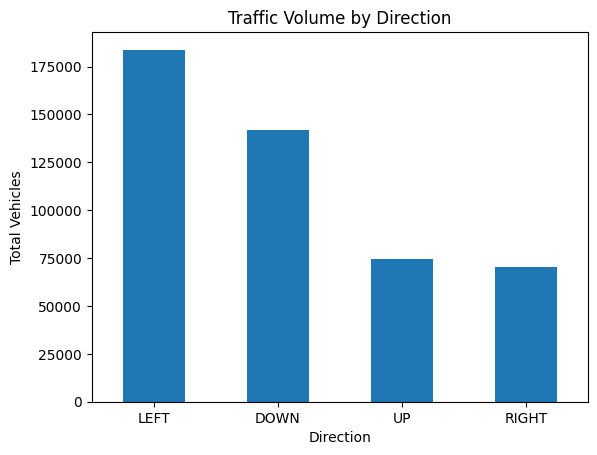

In [32]:
direction_traffic = (
    clean_df.groupby("direction")["total_vehicles"]
    .sum()
    .sort_values(ascending=False)
)

display(direction_traffic)

direction_traffic.plot(kind="bar")

plt.title("Traffic Volume by Direction")
plt.xlabel("Direction")
plt.ylabel("Total Vehicles")
plt.xticks(rotation=0)
plt.show()

In [33]:
traffic_stats

count    9736.000000
mean       48.333402
std        69.576094
min         0.000000
25%         4.000000
50%        24.000000
75%        74.000000
90%       131.000000
95%       153.000000
max      1586.000000
Name: total_vehicles, dtype: float64

In [34]:
def classify_traffic(count):
    if count <= 4:
        return "LOW"
    elif count <= 74:
        return "MEDIUM"
    elif count <= 153:
        return "HIGH"
    else:
        return "VERY_HIGH"

clean_df["traffic_level"] = clean_df["total_vehicles"].apply(
    classify_traffic
)

print(clean_df["traffic_level"].value_counts())

display(
    clean_df[
        [
            "time",
            "intersection",
            "camera",
            "direction",
            "total_vehicles",
            "traffic_level"
        ]
    ].head(20)
)

traffic_level
MEDIUM       4678
LOW          2664
HIGH         1915
VERY_HIGH     479
Name: count, dtype: int64


,time,intersection,camera,direction,total_vehicles,traffic_level
0,1900-01-01 08:55:00,JehangirChowk,j1,DOWN,1.0,LOW
1,1900-01-01 08:55:00,JehangirChowk,j1,LEFT,1.0,LOW
2,1900-01-01 08:55:00,JehangirChowk,j1,RIGHT,0.0,LOW
3,1900-01-01 08:55:00,JehangirChowk,j1,UP,0.0,LOW
4,1900-01-01 09:00:00,JehangirChowk,j1,DOWN,212.0,VERY_HIGH
5,1900-01-01 09:00:00,JehangirChowk,j1,LEFT,59.0,MEDIUM
6,1900-01-01 09:00:00,JehangirChowk,j1,RIGHT,57.0,MEDIUM
7,1900-01-01 09:00:00,JehangirChowk,j1,UP,4.0,LOW
8,1900-01-01 09:05:00,JehangirChowk,j1,DOWN,246.0,VERY_HIGH
9,1900-01-01 09:05:00,JehangirChowk,j1,LEFT,44.0,MEDIUM


In [35]:
extreme = clean_df[
    clean_df["total_vehicles"] > 153
].sort_values("total_vehicles", ascending=False)

print("Observations above 95th percentile:", len(extreme))

display(extreme.head(20))

Observations above 95th percentile: 479


,time,direction,car_count,bike_count,bus_count,truck_count,total_vehicles,intersection,camera,source_file,traffic_level
4355,1900-01-01 10:55:00,UP,1564.0,15.0,6.0,1.0,1586.0,AlankarChowk,a3,a3_15.csv,VERY_HIGH
3743,1900-01-01 09:35:00,UP,1480.0,9.0,1.0,0.0,1490.0,AlankarChowk,a3,a3_12.csv,VERY_HIGH
4331,1900-01-01 10:25:00,UP,1310.0,5.0,1.0,1.0,1317.0,AlankarChowk,a3,a3_15.csv,VERY_HIGH
4367,1900-01-01 11:10:00,UP,1069.0,0.0,2.0,85.0,1156.0,AlankarChowk,a3,a3_15.csv,VERY_HIGH
3895,1900-01-01 10:10:00,UP,1085.0,1.0,1.0,0.0,1087.0,AlankarChowk,a3,a3_13.csv,VERY_HIGH
3911,1900-01-01 10:30:00,UP,1061.0,8.0,3.0,0.0,1072.0,AlankarChowk,a3,a3_13.csv,VERY_HIGH
4599,1900-01-01 10:50:00,UP,919.0,0.0,2.0,1.0,922.0,AlankarChowk,a3,a3_16.csv,VERY_HIGH
4607,1900-01-01 11:00:00,UP,875.0,0.0,7.0,2.0,884.0,AlankarChowk,a3,a3_16.csv,VERY_HIGH
4291,1900-01-01 09:35:00,UP,768.0,19.0,4.0,0.0,791.0,AlankarChowk,a3,a3_15.csv,VERY_HIGH
4603,1900-01-01 10:55:00,UP,761.0,1.0,24.0,0.0,786.0,AlankarChowk,a3,a3_16.csv,VERY_HIGH


In [36]:
VEHICLE_WEIGHTS = {
    "car_count": 1.0,
    "bike_count": 0.5,
    "bus_count": 2.5,
    "truck_count": 3.0
}

clean_df["traffic_pressure"] = (
    clean_df["car_count"] * VEHICLE_WEIGHTS["car_count"]
    + clean_df["bike_count"] * VEHICLE_WEIGHTS["bike_count"]
    + clean_df["bus_count"] * VEHICLE_WEIGHTS["bus_count"]
    + clean_df["truck_count"] * VEHICLE_WEIGHTS["truck_count"]
)

display(
    clean_df[
        [
            "car_count",
            "bike_count",
            "bus_count",
            "truck_count",
            "total_vehicles",
            "traffic_pressure"
        ]
    ].head(20)
)

,car_count,bike_count,bus_count,truck_count,total_vehicles,traffic_pressure
0,1.0,0.0,0.0,0.0,1.0,1.0
1,1.0,0.0,0.0,0.0,1.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0
4,77.0,122.0,3.0,10.0,212.0,175.5
5,58.0,1.0,0.0,0.0,59.0,58.5
6,25.0,19.0,2.0,11.0,57.0,72.5
7,3.0,1.0,0.0,0.0,4.0,3.5
8,111.0,124.0,2.0,9.0,246.0,205.0
9,43.0,0.0,0.0,1.0,44.0,46.0


In [37]:
MIN_GREEN = 15
MAX_GREEN = 60

In [38]:
pressure_reference = clean_df["traffic_pressure"].quantile(0.95)

def recommend_green(pressure):
    normalized = min(pressure / pressure_reference, 1.0)

    green = MIN_GREEN + normalized * (MAX_GREEN - MIN_GREEN)

    return round(green)

clean_df["recommended_green"] = clean_df[
    "traffic_pressure"
].apply(recommend_green)

display(
    clean_df[
        [
            "intersection",
            "direction",
            "total_vehicles",
            "traffic_level",
            "traffic_pressure",
            "recommended_green"
        ]
    ].head(30)
)

,intersection,direction,total_vehicles,traffic_level,traffic_pressure,recommended_green
0,JehangirChowk,DOWN,1.0,LOW,1.0,15
1,JehangirChowk,LEFT,1.0,LOW,1.0,15
2,JehangirChowk,RIGHT,0.0,LOW,0.0,15
3,JehangirChowk,UP,0.0,LOW,0.0,15
4,JehangirChowk,DOWN,212.0,VERY_HIGH,175.5,60
5,JehangirChowk,LEFT,59.0,MEDIUM,58.5,32
6,JehangirChowk,RIGHT,57.0,MEDIUM,72.5,36
7,JehangirChowk,UP,4.0,LOW,3.5,16
8,JehangirChowk,DOWN,246.0,VERY_HIGH,205.0,60
9,JehangirChowk,LEFT,44.0,MEDIUM,46.0,28


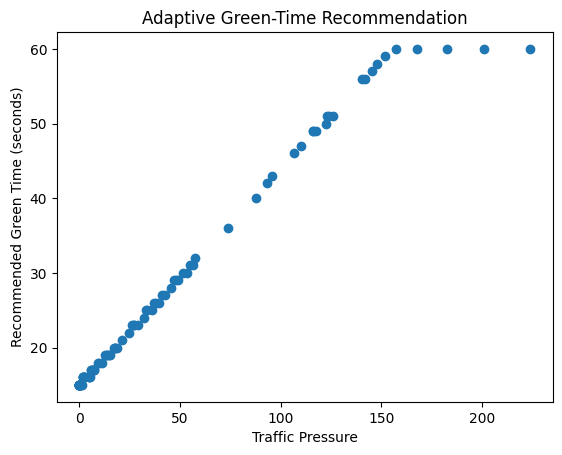

In [39]:
sample = clean_df.sample(
    min(100, len(clean_df)),
    random_state=42
)

plt.scatter(
    sample["traffic_pressure"],
    sample["recommended_green"]
)

plt.xlabel("Traffic Pressure")
plt.ylabel("Recommended Green Time (seconds)")
plt.title("Adaptive Green-Time Recommendation")

plt.show()

In [40]:
OUTPUT_PATH = "../data/processed/pune_traffic_intelligent.csv"

clean_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Saved:")
print(OUTPUT_PATH)

Saved:
../data/processed/pune_traffic_intelligent.csv
